In [1]:
import re
import time
import random
import requests
import matplotlib.pyplot as plt
import numpy as np

from bs4 import BeautifulSoup
from urllib.parse import quote, urlparse
from io import BytesIO
from pathlib import Path
from PIL import Image
from requests.exceptions import RequestException, Timeout, ConnectionError

plt.style.use("dark_background")


# ----------------------------------------------------------------
# Query / folder-name / filename validation
# ----------------------------------------------------------------
# Each query is used in two places on disk:
#   1. As a sub-directory name:  save_dir/<query>/
#   2. As a filename prefix:     save_dir/<query>/<query>_000.jpg
# The same character rules apply to both, so a single validation
# function covers both uses.

# Characters that are illegal in folder/file names on Windows or Unix
_ILLEGAL_CHARS = r'[<>:"/\\|?*\x00-\x1f]'

# Reserved device names on Windows (case-insensitive)
_WINDOWS_RESERVED = {
    "CON", "PRN", "AUX", "NUL",
    *(f"COM{i}" for i in range(1, 10)),
    *(f"LPT{i}" for i in range(1, 10)),
}

# Maximum length (conservative cross-platform limit)
# Kept well under 255 to leave room for the suffix "_000.jpg" (8 chars)
_MAX_FOLDER_NAME_LEN = 200


def validate_query_as_folder_name(query: str) -> str:
    """
    Validate that a query string can be used as both a folder name and
    a filename prefix (e.g. the query becomes "<query>_000.jpg").

    Rules enforced
    --------------
    - Must be a non-empty string after stripping whitespace.
    - Must not contain characters illegal on Windows or Unix:
      < > : " / \\ | ? * and ASCII control characters (0x00-0x1F).
    - Must not be a Windows reserved device name (CON, NUL, COM1, …).
    - Must not exceed 200 characters, leaving headroom for the
      numeric suffix and extension appended to filenames.

    Returns the stripped query on success; raises ValueError on failure.
    """
    if not isinstance(query, str):
        raise TypeError(f"Query must be a str, got {type(query).__name__!r}: {query!r}")

    stripped = query.strip()

    if not stripped:
        raise ValueError(f"Query is empty or whitespace-only: {query!r}")

    illegal = re.findall(_ILLEGAL_CHARS, stripped)
    if illegal:
        chars = ", ".join(repr(c) for c in sorted(set(illegal)))
        raise ValueError(
            f"Query {stripped!r} contains characters that are illegal in folder "
            f"and file names: {chars}"
        )

    if stripped.upper() in _WINDOWS_RESERVED:
        raise ValueError(
            f"Query {stripped!r} is a reserved Windows device name and cannot be "
            "used as a folder name or filename prefix."
        )

    if len(stripped) > _MAX_FOLDER_NAME_LEN:
        raise ValueError(
            f"Query {stripped!r} is {len(stripped)} characters long; "
            f"folder/file names must be at most {_MAX_FOLDER_NAME_LEN} characters."
        )

    return stripped


def validate_all_queries(queries) -> list[str]:
    """
    Validate every query in the list and return the cleaned list.
    Raises ValueError on the first invalid query, with a clear message.
    """
    if not queries:
        raise ValueError("queries list is empty.")

    cleaned = []
    for i, q in enumerate(queries):
        try:
            cleaned.append(validate_query_as_folder_name(q))
        except (TypeError, ValueError) as exc:
            raise ValueError(f"queries[{i}] is invalid: {exc}") from exc

    duplicates = [q for q in set(cleaned) if cleaned.count(q) > 1]
    if duplicates:
        raise ValueError(
            f"queries contains duplicate entries (would overwrite the same folder): "
            + ", ".join(repr(d) for d in duplicates)
        )

    return cleaned


# ----------------------------------------------------------------
# Validation helpers (filters)
# ----------------------------------------------------------------

def validate_aspect_ratio_range(aspect_ratio_range):
    if not isinstance(aspect_ratio_range, (tuple, list)) or len(aspect_ratio_range) != 2:
        raise ValueError(
            "aspect_ratio_range must be a tuple/list of length 2, e.g. (0.8, 1.6)"
        )
    min_ratio, max_ratio = aspect_ratio_range
    if min_ratio <= 0 or max_ratio <= 0:
        raise ValueError("aspect_ratio_range values must be positive")
    if min_ratio > max_ratio:
        raise ValueError("aspect_ratio_range must satisfy min <= max")
    return float(min_ratio), float(max_ratio)


def validate_resolution_threshold(min_resolution):
    if not isinstance(min_resolution, (tuple, list)) or len(min_resolution) != 2:
        raise ValueError(
            "min_resolution must be a tuple/list of length 2, e.g. (180, 120)"
        )
    min_w, min_h = min_resolution
    if min_w <= 0 or min_h <= 0:
        raise ValueError("min_resolution values must be positive")
    return int(min_w), int(min_h)


# ----------------------------------------------------------------
# Image quality filter
# ----------------------------------------------------------------

def passes_image_filters(
    img: Image.Image,
    aspect_ratio_range=(0.8, 1.6),
    min_resolution=(180, 120),
) -> tuple[bool, list[str]]:
    """
    Return (passed, failed_reasons) for a single image.
    failed_reasons is an empty list when the image passes all filters.
    """
    min_ratio, max_ratio = validate_aspect_ratio_range(aspect_ratio_range)
    min_w, min_h = validate_resolution_threshold(min_resolution)

    w, h = img.size
    ar = w / max(h, 1)
    reasons = []

    if w < min_w or h < min_h:
        reasons.append("resolution")
    if not (min_ratio <= ar <= max_ratio):
        reasons.append("aspect_ratio")

    return len(reasons) == 0, reasons


# ----------------------------------------------------------------
# HTTP with retry
# ----------------------------------------------------------------

USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/122.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 13_3) AppleWebKit/537.36 Chrome/121.0.0.0 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36",
]


def get_default_headers() -> dict:
    return {"User-Agent": random.choice(USER_AGENTS)}


def safe_get(url, headers, timeout=15, retries=5, backoff_base=2.0):
    last_exception = None

    for i in range(retries):
        try:
            resp = requests.get(url, headers=headers, timeout=timeout)

            if resp.status_code == 200:
                return resp

            if resp.status_code == 429:
                sleep = (backoff_base ** i) + random.uniform(0.5, 2.0)
                print(f"  Rate limited. Sleeping {sleep:.1f}s")
                time.sleep(sleep)
                continue

            if resp.status_code in {500, 502, 503, 504}:
                sleep = (backoff_base ** i) + random.uniform(0.5, 2.0)
                print(f"  Server error {resp.status_code}. Sleeping {sleep:.1f}s")
                time.sleep(sleep)
                continue

            resp.raise_for_status()

        except (Timeout, ConnectionError) as e:
            last_exception = e
            sleep = (backoff_base ** i) + random.uniform(0.5, 2.0)
            print(f"  Network error ({type(e).__name__}). Sleeping {sleep:.1f}s")
            time.sleep(sleep)

        except RequestException as e:
            last_exception = e
            sleep = (backoff_base ** i) + random.uniform(0.5, 2.0)
            print(f"  Request error ({type(e).__name__}). Sleeping {sleep:.1f}s")
            time.sleep(sleep)

    if last_exception is not None:
        raise last_exception
    raise Exception("Too many retries")


# ----------------------------------------------------------------
# Bing scraping
# ----------------------------------------------------------------

# Bing returns ~28 results per page; `first` is the 1-based result index.
_BING_PAGE_SIZE = 28


def build_bing_url(query: str, page: int = 0) -> str:
    """
    Build a Bing image search URL for the given zero-based page number.
    page=0 → first=1 (first results page)
    page=1 → first=29 (second results page), etc.
    """
    first = page * _BING_PAGE_SIZE + 1
    return f"https://www.bing.com/images/search?q={quote(query)}&first={first}"


def extract_thumbnail_urls(html: str) -> list[str]:
    soup = BeautifulSoup(html, "html.parser")
    urls = []

    for a in soup.select("a.iusc"):
        meta = a.get("m", "")
        marker = '"turl":"'
        start = meta.find(marker)
        if start != -1:
            start += len(marker)
            end = meta.find('"', start)
            if end != -1:
                urls.append(meta[start:end].replace("\\/", "/"))

    # Fallback: grab any <img src> that looks like an external image
    if not urls:
        for img in soup.find_all("img"):
            src = img.get("src")
            if src and src.startswith("http"):
                urls.append(src)

    # Deduplicate while preserving order
    seen, deduped = set(), []
    for u in urls:
        if u not in seen:
            seen.add(u)
            deduped.append(u)

    return deduped


def is_bing_thumbnail_url(url: str) -> bool:
    host = urlparse(url).netloc.lower()
    return host.endswith("bing.net") or ".bing.net" in host


def download_thumbnail(url: str, headers=None, timeout=10) -> Image.Image | None:
    if headers is None:
        headers = get_default_headers()
    if not is_bing_thumbnail_url(url):
        return None
    resp = safe_get(url, headers=headers, timeout=timeout)
    if not resp.headers.get("Content-Type", "").startswith("image/"):
        return None
    try:
        return Image.open(BytesIO(resp.content)).convert("RGB")
    except Exception:
        return None


# ----------------------------------------------------------------
# Multi-page image collection
# ----------------------------------------------------------------

def collect_filtered_images(
    query: str,
    max_images: int,
    max_pages: int,
    aspect_ratio_range: tuple,
    min_resolution: tuple,
    per_image_timeout: int,
) -> list[tuple[str, Image.Image]]:
    """
    Paginate through Bing results page by page, downloading and filtering
    thumbnails, until either max_images passing images have been collected
    or max_pages pages have been searched.

    Returns a list of (url, PIL.Image) pairs that passed all filters.
    """
    headers = get_default_headers()
    collected = []   # (url, img) pairs that passed filters
    seen_urls = set()

    for page in range(max_pages):
        if len(collected) >= max_images:
            break

        url = build_bing_url(query, page=page)
        print(f"  Fetching page {page + 1}/{max_pages} → {url}")

        try:
            resp = safe_get(url, headers=headers)
        except Exception as e:
            print(f"  Failed to fetch search page {page + 1}: {e}")
            break

        thumb_urls = extract_thumbnail_urls(resp.text)

        if not thumb_urls:
            print(f"  No thumbnails found on page {page + 1}. Stopping early.")
            break

        new_urls = [u for u in thumb_urls if u not in seen_urls]
        seen_urls.update(new_urls)

        if not new_urls:
            print(f"  All URLs on page {page + 1} already seen. Stopping early.")
            break

        for thumb_url in new_urls:
            if len(collected) >= max_images:
                break

            try:
                img = download_thumbnail(thumb_url, headers=headers, timeout=per_image_timeout)
            except Exception as e:
                print(f"  Skipping {thumb_url} | {type(e).__name__}: {e}")
                continue

            if img is None:
                continue

            passed, reasons = passes_image_filters(
                img,
                aspect_ratio_range=aspect_ratio_range,
                min_resolution=min_resolution,
            )

            if passed:
                collected.append((thumb_url, img))
                print(f"  Collected {len(collected)}/{max_images} images")

    return collected


# ----------------------------------------------------------------
# Save helpers
# ----------------------------------------------------------------

def save_image(img: Image.Image, path: Path, dpi: int = 200) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)


# ----------------------------------------------------------------
# Top-level dataset builder
# ----------------------------------------------------------------

def build_image_dataset(
    queries: list[str],
    save_dir: str | Path,
    max_images: int = 9,
    max_pages: int = 10,
    aspect_ratio_range: tuple = (0.9, 1.8),
    min_resolution: tuple = (180, 120),
    per_image_timeout: int = 10,
    min_delay: float = 2.0,
    max_delay: float = 5.0,
    continue_on_error: bool = True,
) -> dict:
    """
    Download and save a filtered image dataset from Bing Image Search.

    For each query a sub-directory is created inside save_dir, and all
    images that pass the quality filters are saved there as JPEGs.
    Pagination is used automatically so results are not limited to a
    single search-results page.

    Parameters
    ----------
    queries : list[str]
        Search terms. Each entry becomes its own sub-directory. All
        queries are validated as legal folder names before any network
        requests are made.
    save_dir : str or Path
        Root output directory. Created automatically if it does not exist.
    max_images : int, default 9
        Maximum number of filter-passing images to save per query. The
        scraper stops as soon as this count is reached, even if more
        pages are available.
    max_pages : int, default 10
        Maximum number of Bing results pages to search per query. Acts
        as a safety limit so the scraper does not run forever if a query
        has few good results. Each page contains approximately 28 results.
    aspect_ratio_range : tuple of (float, float), default (0.9, 1.8)
        Inclusive (min, max) bounds on image aspect ratio w/h. Images
        outside this range are discarded. For example, (0.9, 1.8) accepts
        roughly square to moderately wide images while rejecting very tall
        portraits and extreme panoramas.
    min_resolution : tuple of (int, int), default (180, 120)
        Minimum acceptable (width, height) in pixels. Images smaller than
        either dimension are discarded.
    per_image_timeout : int, default 10
        Seconds to wait for a single thumbnail download before skipping it.
    min_delay : float, default 2.0
        Lower bound of the random sleep (in seconds) inserted between
        queries to avoid triggering Bing rate-limiting.
    max_delay : float, default 5.0
        Upper bound of the random sleep (in seconds) between queries.
    continue_on_error : bool, default True
        If True, a failed query is logged and the loop moves on to the
        next one. If False, the first failure raises an exception and
        halts the entire run.

    Returns
    -------
    dict
        Summary with keys:
        - "results": per-query dict with keys "saved", "status", "error"
        - "total_saved": total images saved across all queries
        - "save_dir": resolved absolute path of the output directory
    """
    # --- validate everything before touching the network ----------------
    cleaned_queries = validate_all_queries(queries)
    validate_aspect_ratio_range(aspect_ratio_range)
    validate_resolution_threshold(min_resolution)

    save_dir = Path(save_dir).resolve()
    save_dir.mkdir(parents=True, exist_ok=True)

    summary = {"results": {}, "total_saved": 0, "save_dir": str(save_dir)}

    for i, query in enumerate(cleaned_queries):
        print(f"\n[{i + 1}/{len(cleaned_queries)}] query={query!r}")

        query_dir = save_dir / query
        query_dir.mkdir(parents=True, exist_ok=True)

        n_saved = 0
        status = "ok"
        error_msg = None

        try:
            images = collect_filtered_images(
                query=query,
                max_images=max_images,
                max_pages=max_pages,
                aspect_ratio_range=aspect_ratio_range,
                min_resolution=min_resolution,
                per_image_timeout=per_image_timeout,
            )

            for idx, (url, img) in enumerate(images):
                out_path = query_dir / f"{query}_{idx:03d}.jpg"
                save_image(img, out_path)
                n_saved += 1

            print(f"  Saved {n_saved} images → {query_dir}")

        except Exception as e:
            status = "error"
            error_msg = f"{type(e).__name__}: {e}"
            print(f"  FAILED: {query!r} | {error_msg}")

            if not continue_on_error:
                raise

        summary["results"][query] = {
            "saved": n_saved,
            "status": status,
            "error": error_msg,
        }
        summary["total_saved"] += n_saved

        if i < len(cleaned_queries) - 1:
            delay = random.uniform(min_delay, max_delay)
            print(f"  Sleeping {delay:.1f}s before next query…")
            time.sleep(delay)

    print(f"\nDone. {summary['total_saved']} total images saved to {save_dir}")
    return summary


# ----------------------------------------------------------------
# Example usage
# ----------------------------------------------------------------
folder_path = "images/"

summary = build_image_dataset(
    queries=[
        "dog",
        "cat",
    ],
    save_dir=folder_path,
    max_images=100,
    max_pages=30,
    aspect_ratio_range=(0.5, 2.0),
    min_resolution=(100, 100),
    per_image_timeout=10,
    min_delay=2,
    max_delay=5,
    continue_on_error=True,
)


[1/2] query='dog'
  Fetching page 1/30 → https://www.bing.com/images/search?q=dog&first=1
  Collected 1/100 images
  Collected 2/100 images
  Collected 3/100 images
  Collected 4/100 images
  Collected 5/100 images
  Collected 6/100 images
  Collected 7/100 images
  Collected 8/100 images
  Collected 9/100 images
  Collected 10/100 images
  Collected 11/100 images
  Collected 12/100 images
  Collected 13/100 images
  Collected 14/100 images
  Collected 15/100 images
  Collected 16/100 images
  Collected 17/100 images
  Collected 18/100 images
  Collected 19/100 images
  Collected 20/100 images
  Collected 21/100 images
  Collected 22/100 images
  Collected 23/100 images
  Collected 24/100 images
  Collected 25/100 images
  Collected 26/100 images
  Collected 27/100 images
  Collected 28/100 images
  Collected 29/100 images
  Collected 30/100 images
  Collected 31/100 images
  Collected 32/100 images
  Collected 33/100 images
  Collected 34/100 images
  Fetching page 2/30 → https://www

In [5]:
from pathlib import Path
from PIL import Image


def load_image_dataset(dataset_dir: str | Path) -> tuple[list[Image.Image], list[str]]:
    """
    Load all images from a flat two-level dataset directory.

    Expected structure
    ------------------
    dataset_dir/
    ├── class_a/
    │   ├── class_a_000.jpg
    │   └── class_a_001.jpg
    ├── class_b/
    │   └── class_b_000.jpg
    └── ...

    Each immediate subdirectory is treated as a class. Files that cannot
    be opened as images are skipped with a warning. Subdirectories nested
    deeper than one level are ignored.

    Parameters
    ----------
    dataset_dir : str or Path
        Path to the root dataset folder.

    Returns
    -------
    images : list of PIL.Image
        One entry per successfully loaded image, in RGB mode.
    labels : list of str
        Parallel list of class label strings (the subdirectory name)
        corresponding to each image.
    """
    dataset_dir = Path(dataset_dir).resolve()

    if not dataset_dir.exists():
        raise FileNotFoundError(f"Dataset directory not found: {dataset_dir}")
    if not dataset_dir.is_dir():
        raise NotADirectoryError(f"Path is not a directory: {dataset_dir}")

    class_dirs = sorted(p for p in dataset_dir.iterdir() if p.is_dir())

    if not class_dirs:
        raise ValueError(f"No subdirectories found in {dataset_dir}")

    images, labels = [], []

    for class_dir in class_dirs:
        class_name = class_dir.name
        image_files = sorted(
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        )

        if not image_files:
            print(f"  Warning: no image files found in class folder {class_name!r}, skipping.")
            continue

        n_loaded = 0
        for img_path in image_files:
            try:
                img = Image.open(img_path).convert("RGB")
                img.load()  # force decode now rather than lazily on first use
                images.append(img)
                labels.append(class_name)
                n_loaded += 1
            except Exception as e:
                print(f"  Warning: could not load {img_path.name} ({type(e).__name__}: {e}), skipping.")

        print(f"  {class_name!r}: loaded {n_loaded}/{len(image_files)} images")

    print(f"\nTotal: {len(images)} images across {len(class_dirs)} classes")
    return images, labels

folder_path = "images/"

images, labels = load_image_dataset(folder_path)

  'cat': loaded 100/100 images
  'dog': loaded 79/79 images

Total: 179 images across 2 classes


In [6]:
import numpy as np
from PIL import Image

def preprocess_image_dataset(
    images: list[Image.Image],
    labels: list[str],
    target_size: tuple[int, int] = (224, 224),
) -> tuple[np.ndarray, np.ndarray, dict[str, int]]:
    """
    Resize all images to a standard size and label-encode class strings.

    Parameters
    ----------
    images : list of PIL.Image
        Raw images as returned by load_image_dataset. May be any resolution.
    labels : list of str
        Parallel list of class label strings.
    target_size : tuple of (int, int), default (224, 224)
        Target (width, height) in pixels. All images are resized to this
        shape regardless of their original aspect ratio.

    Returns
    -------
    X : np.ndarray, shape (N, height, width, 3), dtype float32
        Pixel values normalized to [0, 1].
    y : np.ndarray, shape (N,), dtype int64
        Integer class index for each image.
    label_map : dict[str, int]
        Mapping from class name to integer index, e.g.
        {"cat": 0, "dog": 1}. Sorted alphabetically so the
        mapping is deterministic.
    """
    if len(images) != len(labels):
        raise ValueError(
            f"images and labels must have the same length "
            f"(got {len(images)} and {len(labels)})"
        )
    if len(images) == 0:
        raise ValueError("images list is empty.")

    if (
        not isinstance(target_size, (tuple, list))
        or len(target_size) != 2
        or target_size[0] <= 0
        or target_size[1] <= 0
    ):
        raise ValueError(
            "target_size must be a (width, height) tuple of positive integers."
        )

    target_size = (int(target_size[0]), int(target_size[1]))
    w, h = target_size

    # --- label encoding -------------------------------------------------
    label_map = {name: idx for idx, name in enumerate(sorted(set(labels)))}
    y = np.array([label_map[l] for l in labels], dtype=np.int64)

    # --- resize + normalize ---------------------------------------------
    X = np.empty((len(images), h, w, 3), dtype=np.float32)

    for i, img in enumerate(images):
        resized = img.resize(target_size, Image.LANCZOS)
        X[i] = np.asarray(resized, dtype=np.float32) / 255.0

    print(f"X shape : {X.shape}  dtype={X.dtype}")
    print(f"y shape : {y.shape}  dtype={y.dtype}")
    print(f"Classes : {label_map}")

    return X, y, label_map

X, y, label_map = preprocess_image_dataset(
    images=images,
    labels=labels,
    target_size=(224, 224),
)

X shape : (179, 224, 224, 3)  dtype=float32
y shape : (179,)  dtype=int64
Classes : {'cat': 0, 'dog': 1}


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

In [8]:
from tensorflow.keras.applications import EfficientNetV2M
from tensorflow.keras.applications import MobileNetV2

# Load EfficientNetB3 without top layer
#base_model = EfficientNetV2M(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Display model summary
#base_model.summary()

In [9]:
## Get pre-trained features

# Extract features using the pre-trained model
X_train_encoded = base_model.predict(X_train, verbose=1)
X_test_encoded = base_model.predict(X_test, verbose=1)

print("X_train_encoded.shape:", X_train_encoded.shape)
print("X_test_encoded.shape: ", X_test_encoded.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 383ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step 
X_train_encoded.shape: (143, 7, 7, 1280)
X_test_encoded.shape:  (36, 7, 7, 1280)


In [10]:
## Create / train simple dense head

from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

n_classes  = np.unique(y_train).shape[0]

# Create a classification head
input_encoded = Input(shape=X_train_encoded.shape[1:])
x = Flatten()(input_encoded)
x = Dropout(0.5)(x)
outputs = Dense(n_classes, activation='softmax')(x)

# Build the model
model = Model(inputs=input_encoded, outputs=outputs)

model.summary()

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs     = 50
batch_size = 200

optimizer = Adam(
    learning_rate=0.001,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=20,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 7, 7, 1280)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 62720)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 62720)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │         125,442 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 125,442 (490.01 KB)

 Trainable params: 125,442 (490.01 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train_encoded, y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_test_encoded, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step - accuracy: 0.4545 - loss: 2.0800 - val_accuracy: 0.5556 - val_loss: 8.0337
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5874 - loss: 7.1708 - val_accuracy: 0.7778 - val_loss: 1.2747
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8252 - loss: 0.9716 - val_accuracy: 0.8889 - val_loss: 0.9067
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9790 - loss: 0.0688 - val_accuracy: 0.7222 - val_loss: 3.8353
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9231 - loss: 0.6061 - val_accuracy: 0.6944 - val_loss: 5.8892
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8601 - loss: 1.0655 - val_accuracy: 0.6944 - val_loss: 5.2330
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9091 - loss: 0.4884 - val_accuracy: 0.7500 - val_loss: 3.5711
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9790 - loss: 0.0882 - val_accuracy: 0.8889 - val_loss: 2.4886

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


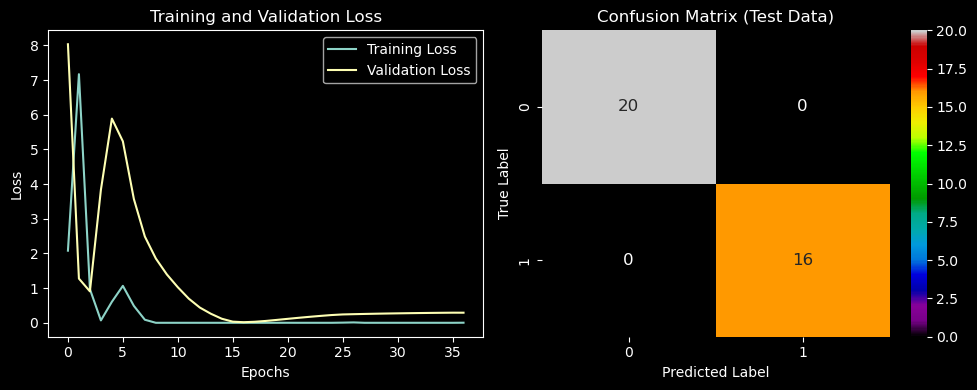

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        16

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [13]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get predictions
y_test_pred  = model.predict(X_test_encoded).argmax(axis=1)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left subplot: Training and Validation Loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
#axes[0].set_yscale('log')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Right subplot: Confusion Matrix (Test Data) using seaborn heatmap with vmin set to 0
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1], vmin=0, 
            annot_kws={"size": 12}, cmap='nipy_spectral')
axes[1].set_title('Confusion Matrix (Test Data)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Print classification report for test data
report = classification_report(y_test, y_test_pred)
print(report)